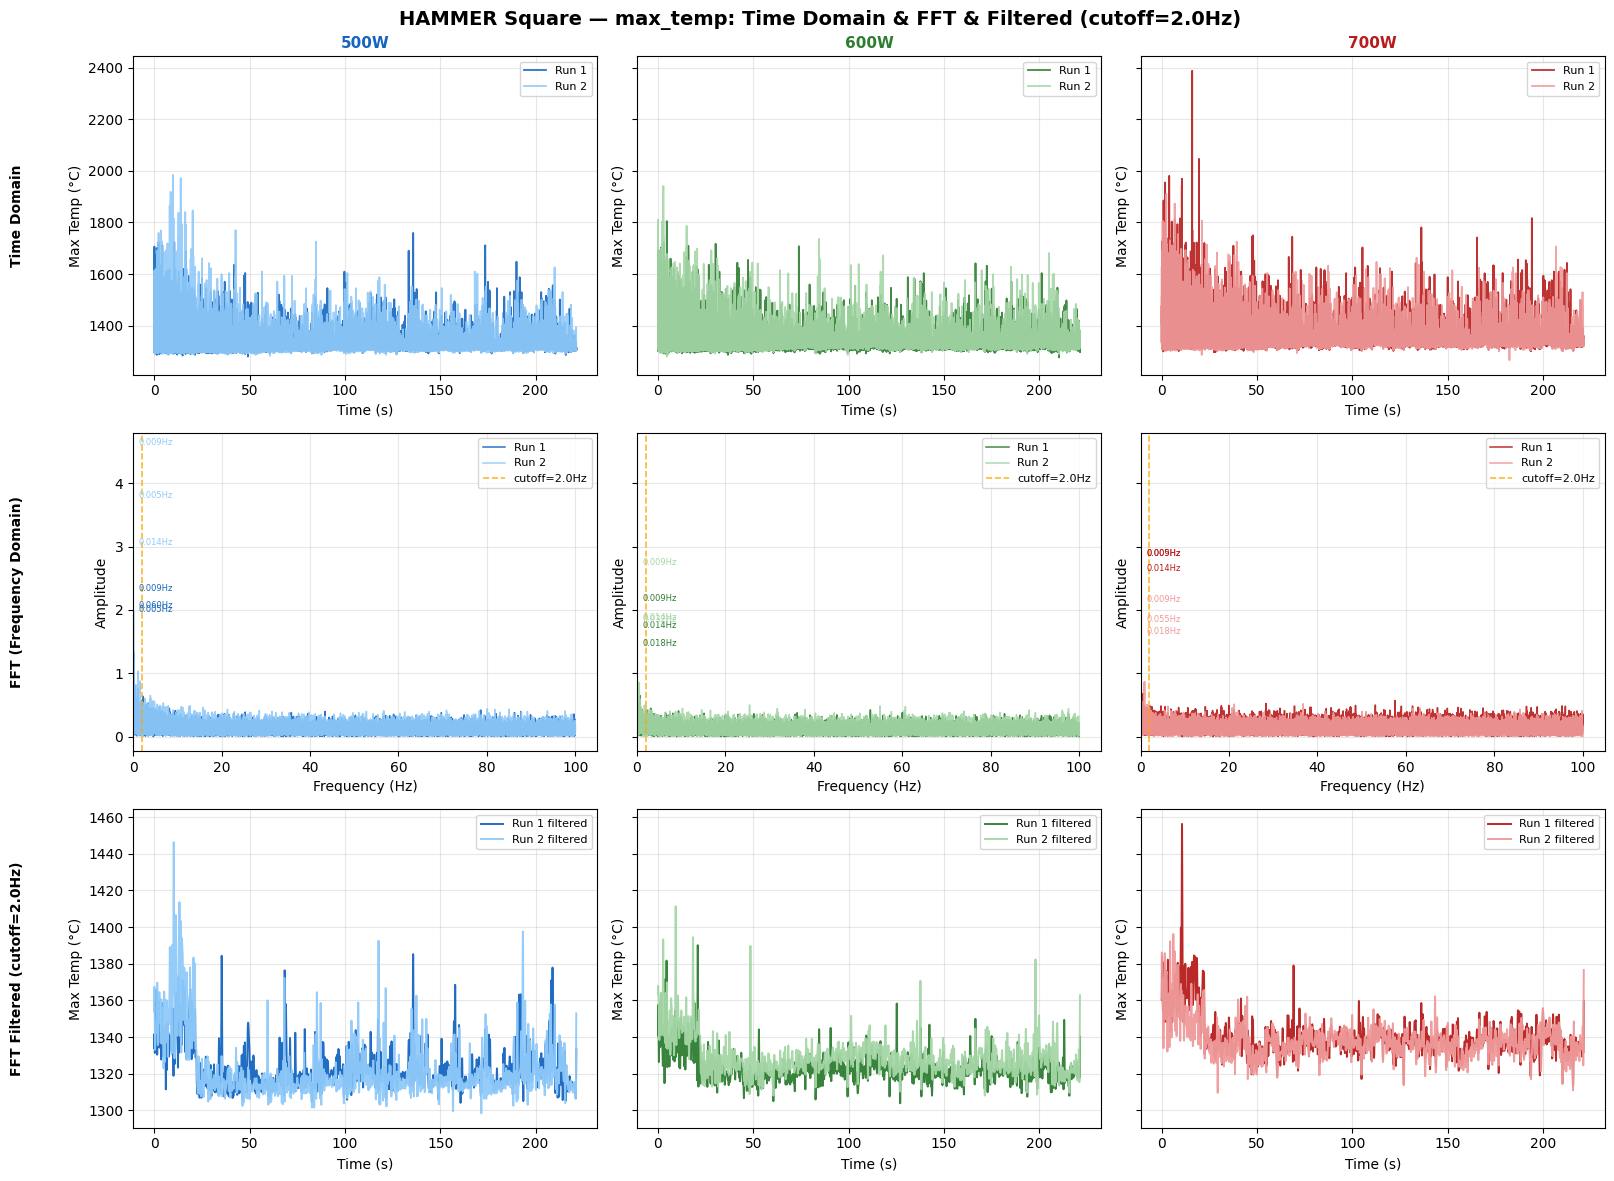

✅ Figure 1 완료!


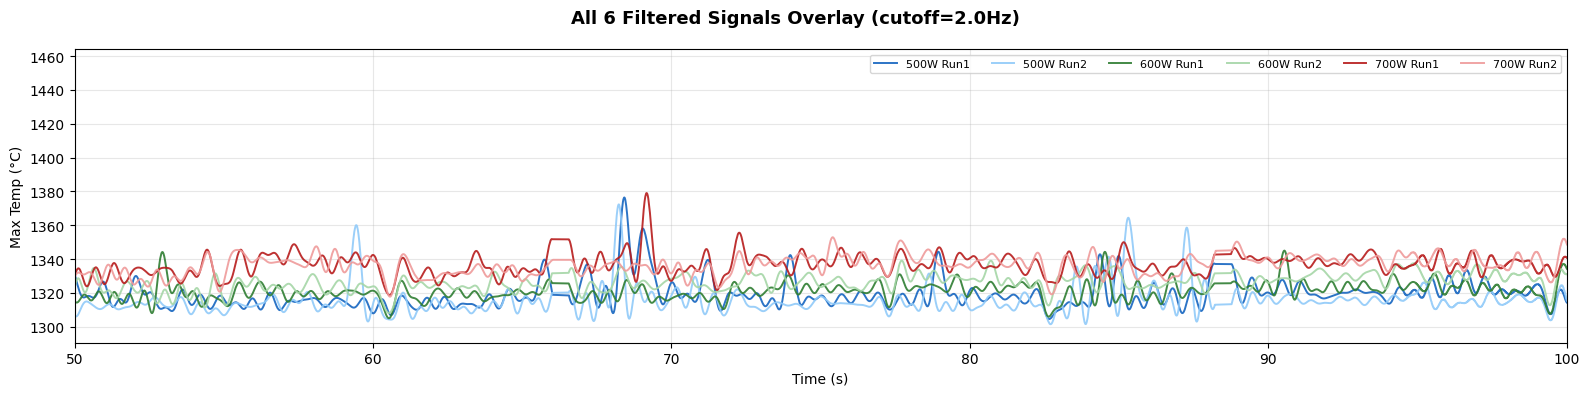

✅ Figure 2 완료!


In [ ]:
"""
HAMMER Square — time_value vs max_temp + FFT
500W / 600W / 700W 각 2개 파일
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ─── ✅ 여기만 바꾸면 전체 적용 ───────────────────────────────────────────────
CUTOFF_HZ = 2.0
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR = Path("/home/ftk3187/github/DPC_research/DATAFUSION/data_0422_rgb")

FILES = {
    "500W": ["HAMMER_Square_500W_1_7.csv",   "HAMMER_Square_500W_2_9.csv"],
    "600W": ["HAMMER_Square_600W_1_12.csv", "HAMMER_Square_600W_2_13.csv"],
    "700W": ["HAMMER_Square_700W_1_10.csv",  "HAMMER_Square_700W_2_11.csv"],
}

WATT_PALETTE = {
    "500W": ["#1565C0", "#90CAF9"],
    "600W": ["#2E7D32", "#A5D6A7"],
    "700W": ["#B71C1C", "#EF9A9A"],
}

# ─── 데이터 로드 ──────────────────────────────────────────────────────────────
all_data = {}
for watt, fnames in FILES.items():
    dfs = []
    for fname in fnames:
        df = pd.read_csv(DATA_DIR / fname)
        df.columns = df.columns.str.strip()
        df["time_norm"] = df["time_value"] - df["time_value"].iloc[0]
        dfs.append(df)
    all_data[watt] = dfs

# ─── Figure 1: 3열(와트) × 3행(Time / FFT / Filtered) ────────────────────────
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), sharey="row")
fig.suptitle(f"HAMMER Square — max_temp: Time Domain & FFT & Filtered (cutoff={CUTOFF_HZ}Hz)",
             fontsize=14, fontweight="bold")

ROW_LABELS = ["Time Domain", "FFT (Frequency Domain)", f"FFT Filtered (cutoff={CUTOFF_HZ}Hz)"]

for col_idx, (watt, dfs) in enumerate(all_data.items()):
    colors = WATT_PALETTE[watt]

    # ── 행 0: 시계열 ──────────────────────────────────────────────────────────
    ax_t = axes[0, col_idx]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        ax_t.plot(df["time_norm"], df["max_temp"],
                  color=color, linewidth=1.3, alpha=0.9, label=f"Run {run_idx+1}")
    ax_t.set_title(watt, fontsize=11, fontweight="bold", color=colors[0])
    ax_t.set_xlabel("Time (s)")
    ax_t.set_ylabel("Max Temp (°C)")
    ax_t.legend(fontsize=8)
    ax_t.grid(True, alpha=0.3)

    # ── 행 1: FFT ─────────────────────────────────────────────────────────────
    ax_f = axes[1, col_idx]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        sig = df["max_temp"].values
        n   = len(sig)
        dt  = df["time_norm"].diff().median()

        fft_vals = np.fft.rfft(sig - sig.mean())
        fft_freq = np.fft.rfftfreq(n, d=dt)
        fft_amp  = np.abs(fft_vals) / n

        ax_f.plot(fft_freq, fft_amp,
                  color=color, linewidth=1.1, alpha=0.9, label=f"Run {run_idx+1}")

        peak_idx = np.argsort(fft_amp)[-3:][::-1]
        for pi in peak_idx:
            ax_f.axvline(fft_freq[pi], color=color, linewidth=0.6, linestyle="--", alpha=0.5)
            ax_f.annotate(f"{fft_freq[pi]:.3f}Hz",
                          xy=(fft_freq[pi], fft_amp[pi]),
                          fontsize=6, color=color,
                          xytext=(4, 2), textcoords="offset points")

    ax_f.axvline(CUTOFF_HZ, color="orange", linewidth=1.2, linestyle="--", alpha=0.8, label=f"cutoff={CUTOFF_HZ}Hz")
    ax_f.set_xlabel("Frequency (Hz)")
    ax_f.set_ylabel("Amplitude")
    ax_f.legend(fontsize=8)
    ax_f.grid(True, alpha=0.3)
    ax_f.set_xlim(left=0)

    # ── 행 2: Filtered ────────────────────────────────────────────────────────
    ax_filt = axes[2, col_idx]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        sig = df["max_temp"].values
        n   = len(sig)
        dt  = df["time_norm"].diff().median()

        fft_vals     = np.fft.rfft(sig)
        fft_freq     = np.fft.rfftfreq(n, d=dt)
        fft_filtered = fft_vals.copy()
        fft_filtered[fft_freq > CUTOFF_HZ] = 0
        sig_filtered = np.fft.irfft(fft_filtered, n=n)

        ax_filt.plot(df["time_norm"], sig_filtered,
                     color=color, linewidth=1.4, alpha=0.95, label=f"Run {run_idx+1} filtered")

    ax_filt.set_xlabel("Time (s)")
    ax_filt.set_ylabel("Max Temp (°C)")
    ax_filt.legend(fontsize=8)
    ax_filt.grid(True, alpha=0.3)

for row_idx, label in enumerate(ROW_LABELS):
    axes[row_idx, 0].annotate(
        label, xy=(-0.25, 0.5), xycoords="axes fraction",
        fontsize=10, fontweight="bold", rotation=90,
        va="center", ha="center",
    )

plt.tight_layout()
plt.show()
print("✅ Figure 1 완료!")

# ─── Figure 2: 6개 filtered 전체 오버레이 ────────────────────────────────────
fig2, ax_all = plt.subplots(figsize=(16, 4))
fig2.suptitle(f"All 6 Filtered Signals Overlay (cutoff={CUTOFF_HZ}Hz)", fontsize=13, fontweight="bold")

for watt, dfs in all_data.items():
    colors = WATT_PALETTE[watt]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        sig = df["max_temp"].values
        n   = len(sig)
        dt  = df["time_norm"].diff().median()

        fft_vals     = np.fft.rfft(sig)
        fft_freq     = np.fft.rfftfreq(n, d=dt)
        fft_filtered = fft_vals.copy()
        fft_filtered[fft_freq > CUTOFF_HZ] = 0
        sig_filtered = np.fft.irfft(fft_filtered, n=n)

        ax_all.plot(df["time_norm"], sig_filtered,
                    color=color, linewidth=1.4, alpha=0.9,
                    label=f"{watt} Run{run_idx+1}")

ax_all.set_xlabel("Time (s)")
ax_all.set_ylabel("Max Temp (°C)")
ax_all.set_xlim(50, 100)
ax_all.legend(fontsize=8, ncol=6, loc="upper right")
ax_all.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Figure 2 완료!")

In [4]:
# ─── 5. 3개 Simulation → 400W extrapolation ───
TARGET_W = 400

# lp별 (time, temp, laser_power) 준비
FILE_FULL = "/home/ftk3187/github/DPC_research/DATAFUSION/merged_df_2_99_temp_depth.csv"
df_all_full = pd.read_csv(FILE_FULL, usecols=["time_index", "melt_pool_temperature",
                                               "laser_power_number", "Laser_power"])
sim_data = {}
for lp in LP_LIST:
    df_lp   = df_all_full[df_all_full["laser_power_number"] == lp].reset_index(drop=True)
    temp_ma = moving_average_1d(df_lp["melt_pool_temperature"].values / 2 - 273, WINDOW)
    time_ma = df_lp["time_index"].values[WINDOW - 1:] + TIME_SHIFT
    pwr_ma  = df_lp["Laser_power"].values[WINDOW - 1:]   # temp_ma와 길이 맞춤
    sim_data[lp] = {"time": time_ma, "temp": temp_ma, "power": pwr_ma}

# 공통 time axis
t_start  = max(d["time"][0]  for d in sim_data.values())
t_end    = min(d["time"][-1] for d in sim_data.values())
t_common = np.linspace(t_start, t_end, 1000)

# 공통 time에 temp, power interpolate
interp_temp  = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["temp"])  for lp in LP_LIST}
interp_power = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["power"]) for lp in LP_LIST}

# time step마다 3점 선형 회귀 → 400W extrapolation
temp_extrap = np.zeros(len(t_common))
for i in range(len(t_common)):
    X = np.array([interp_power[lp][i] for lp in LP_LIST])  # 그 순간 각 lp의 Laser_power
    Y = np.array([interp_temp[lp][i]  for lp in LP_LIST])  # 그 순간 각 lp의 온도
    coeffs = np.polyfit(X, Y, 1)
    temp_extrap[i] = np.polyval(coeffs, TARGET_W)

# ── 여기서 플롯 ──
ax.plot(t_common, temp_extrap,
        color="royalblue", linestyle="-", linewidth=1.6, alpha=0.9,
        label="Simulation 400W (extrapolated)")

NameError: name 'LP_LIST' is not defined

400W trimmed: 9218141 → 7990811 samples  (280934 ~ 8271744)


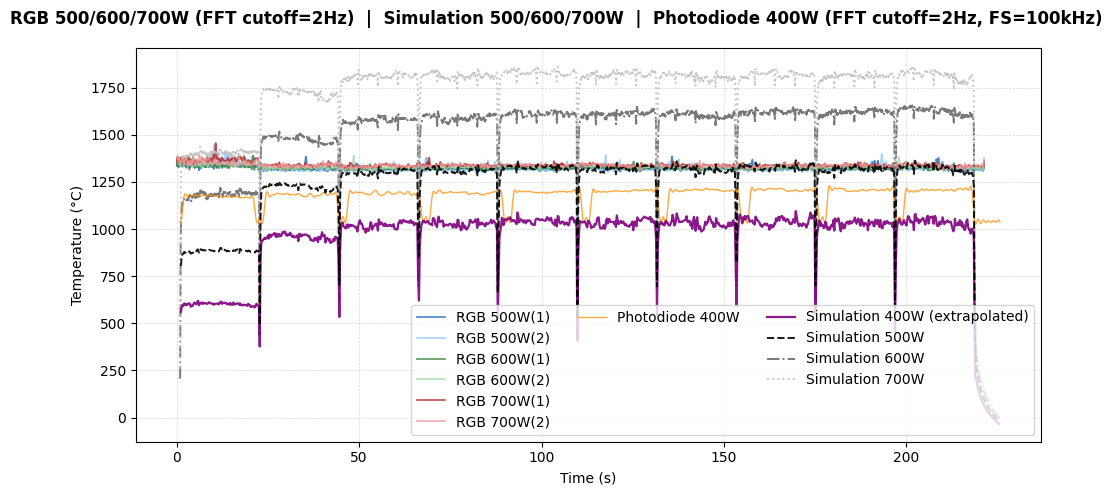

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1. HAMMER filtered 신호 ───
CUTOFF_HZ = 2

def get_filtered(df, cutoff=CUTOFF_HZ):
    sig = df["max_temp"].values
    n   = len(sig)
    dt  = df["time_norm"].diff().median()
    fft_vals     = np.fft.rfft(sig)
    fft_freq     = np.fft.rfftfreq(n, d=dt)
    fft_filtered = fft_vals.copy()
    fft_filtered[fft_freq > cutoff] = 0
    return np.fft.irfft(fft_filtered, n=n)

WATT_PALETTE = {
    "500W": ["#1565C0", "#90CAF9"],
    "600W": ["#2E7D32", "#A5D6A7"],
    "700W": ["#B71C1C", "#EF9A9A"],
}

# ─── 2. melt_pool_temperature + Laser_power ───
FILE_FULL = "/home/ftk3187/github/DPC_research/DATAFUSION/merged_df_2_99_temp_depth.csv"
df_all_full = pd.read_csv(FILE_FULL, usecols=["time_index", "melt_pool_temperature",
                                               "laser_power_number", "Laser_power"])

LP_STYLE = {
    91: {"color": "dimgray", "linestyle": "-.", "label": "Simulation 600W"},
    82: {"color": "silver",  "linestyle": ":",  "label": "Simulation 700W"},
}
LP_LIST = [38, 91, 82]          # extrapolation엔 38 포함
LP_PLOT_LIST = [91, 82]         # 플롯은 600W, 700W만 (500W는 extrap으로 대체)

def moving_average_1d(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='valid')

WINDOW     = 4
TIME_SHIFT = 0.8

# ─── 3. 400W CSV 로드 및 전처리 + FFT ───
FILE_400W = "/home/ftk3187/github/DPC_research/DATAFUSION/data_400w/HT1-3-(240820)_PD_exp02_Single Track Square.csv"
df_400w = pd.read_csv(FILE_400W, header=None)
raw     = df_400w.iloc[:, 2].values

first_valid = max(0,          np.argmax(raw >= 1120) - 30000)
last_valid  = min(len(raw)-1, len(raw) - 1 - np.argmax(raw[::-1] >= 1120) + 260000)
raw_trimmed = raw[first_valid : last_valid + 1]
print(f"400W trimmed: {len(raw)} → {len(raw_trimmed)} samples  ({first_valid} ~ {last_valid})")

FS = 100_000
dt = 1 / FS
n  = len(raw_trimmed)

fft_vals     = np.fft.rfft(raw_trimmed - raw_trimmed.mean())
fft_freq     = np.fft.rfftfreq(n, d=dt)
fft_filtered = fft_vals.copy()
fft_filtered[fft_freq > CUTOFF_HZ] = 0
temp_400w_filtered = np.fft.irfft(fft_filtered, n=n) + raw_trimmed.mean()

df_ref    = df_all_full[df_all_full["laser_power_number"] == 38].reset_index(drop=True)
time_ref  = df_ref["time_index"].values
t_min_ref = time_ref[0]  + TIME_SHIFT
t_max_ref = time_ref[-1] + TIME_SHIFT
time_400w = np.linspace(t_min_ref, t_max_ref, len(temp_400w_filtered))

# ─── 4. sim_data 준비 (38, 91, 82 모두) ───
sim_data = {}
for lp in LP_LIST:
    df_lp   = df_all_full[df_all_full["laser_power_number"] == lp].reset_index(drop=True)
    temp_ma = moving_average_1d(df_lp["melt_pool_temperature"].values / 2 - 273, WINDOW)
    time_ma = df_lp["time_index"].values[WINDOW - 1:] + TIME_SHIFT
    pwr_ma  = df_lp["Laser_power"].values[WINDOW - 1:]
    sim_data[lp] = {"time": time_ma, "temp": temp_ma, "power": pwr_ma}

# 공통 time axis
t_start  = max(d["time"][0]  for d in sim_data.values())
t_end    = min(d["time"][-1] for d in sim_data.values())
t_common = np.linspace(t_start, t_end, 1000)

interp_temp  = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["temp"])  for lp in LP_LIST}
interp_power = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["power"]) for lp in LP_LIST}

# ─── 5. extrapolation — 400W & 500W ───
def extrapolate(target_w):
    result = np.zeros(len(t_common))
    for i in range(len(t_common)):
        X = np.array([interp_power[lp][i] for lp in LP_LIST])
        Y = np.array([interp_temp[lp][i]  for lp in LP_LIST])
        coeffs = np.polyfit(X, Y, 1)
        result[i] = np.polyval(coeffs, target_w)
    return result

temp_extrap_400 = extrapolate(400)
temp_extrap_500 = extrapolate(500)

# ─── 6. 오버레이 플롯 ───
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    f"RGB 500/600/700W (FFT cutoff={CUTOFF_HZ}Hz)  |  Simulation 500/600/700W  |  Photodiode 400W (FFT cutoff={CUTOFF_HZ}Hz, FS={FS//1000}kHz)",
    fontsize=12, fontweight="bold"
)

# HAMMER 6개
# HAMMER 라벨 변경 — 플롯할 때 label 수정
for watt, dfs in all_data.items():
    colors = WATT_PALETTE[watt]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        sig_f = get_filtered(df)
        t     = df["time_norm"].values[:len(sig_f)]
        ax.plot(t, sig_f, color=color, linewidth=1.2, alpha=0.8,
                label=f"RGB {watt}({run_idx+1})")  # ← 라벨 변경

# Simulation 600W, 700W만 플롯
for lp in LP_PLOT_LIST:
    style   = LP_STYLE[lp]
    ax.plot(sim_data[lp]["time"], sim_data[lp]["temp"],
            color=style["color"], linestyle=style["linestyle"],
            linewidth=1.4, alpha=0.9,
            label=style["label"])

# 400W Photodiode
ax.plot(time_400w, temp_400w_filtered,
        color="darkorange", linestyle="-", linewidth=1.0, alpha=0.75,
        label="Photodiode 400W")

# extrapolated
ax.plot(t_common, temp_extrap_400,
        color="purple", linestyle="-", linewidth=1.6, alpha=0.9,
        label="Simulation 400W (extrapolated)")

ax.plot(t_common, temp_extrap_500,
        color="black", linestyle="--", linewidth=1.4, alpha=0.9,
        label="Simulation 500W")

ax.set_ylabel("Temperature (°C)", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=10)
ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.5)
# 이 줄 지우고
# ax.legend(fontsize=8, ncol=4, loc="lower right")

# 아래로 교체
handles, labels = ax.get_legend_handles_labels()

# 순서: RGB 6개 / Photodiode 400W / Simulation 400~700
# 플롯 순서대로 핸들 분리
rgb_h    = handles[:6];   rgb_l    = labels[:6]    # RGB 500W(1),(2) / 600W(1),(2) / 700W(1),(2)
sim600_h = handles[6];    sim600_l = labels[6]     # Simulation 600W
sim700_h = handles[7];    sim700_l = labels[7]     # Simulation 700W
pd400_h  = handles[8];    pd400_l  = labels[8]     # Photodiode 400W
ext400_h = handles[9];    ext400_l = labels[9]     # Simulation 400W (extrapolated)
ext500_h = handles[10];   ext500_l = labels[10]    # Simulation 500W

from matplotlib.patches import Patch
blank = Patch(visible=False, label="")

# 열 맞추기: 6행 3열 → 각 열 6개씩
# col1: RGB 6개
# col2: Photodiode 400W + 빈칸 5개
# col3: Sim 400, 500, 600, 700 + 빈칸 2개
col1_h = rgb_h
col1_l = rgb_l

col2_h = [pd400_h] + [blank]*5
col2_l = [pd400_l] + [""]*5

col3_h = [ext400_h, ext500_h, sim600_h, sim700_h] + [blank]*2
col3_l = [ext400_l, ext500_l, sim600_l, sim700_l] + [""]*2

# ncol=3이면 matplotlib이 행 우선으로 채우므로 열 우선으로 재배열
n_rows = 6
all_h = [col1_h[i] if i < len(col1_h) else blank for i in range(n_rows)] + \
        [col2_h[i] if i < len(col2_h) else blank for i in range(n_rows)] + \
        [col3_h[i] if i < len(col3_h) else blank for i in range(n_rows)]
all_l = [col1_l[i] if i < len(col1_l) else ""    for i in range(n_rows)] + \
        [col2_l[i] if i < len(col2_l) else ""     for i in range(n_rows)] + \
        [col3_l[i] if i < len(col3_l) else ""     for i in range(n_rows)]

ax.legend(all_h, all_l, fontsize=10, ncol=3, loc="lower right")

plt.tight_layout()
plt.show()

400W trimmed: 9218141 → 7990811 samples  (280934 ~ 8271744)


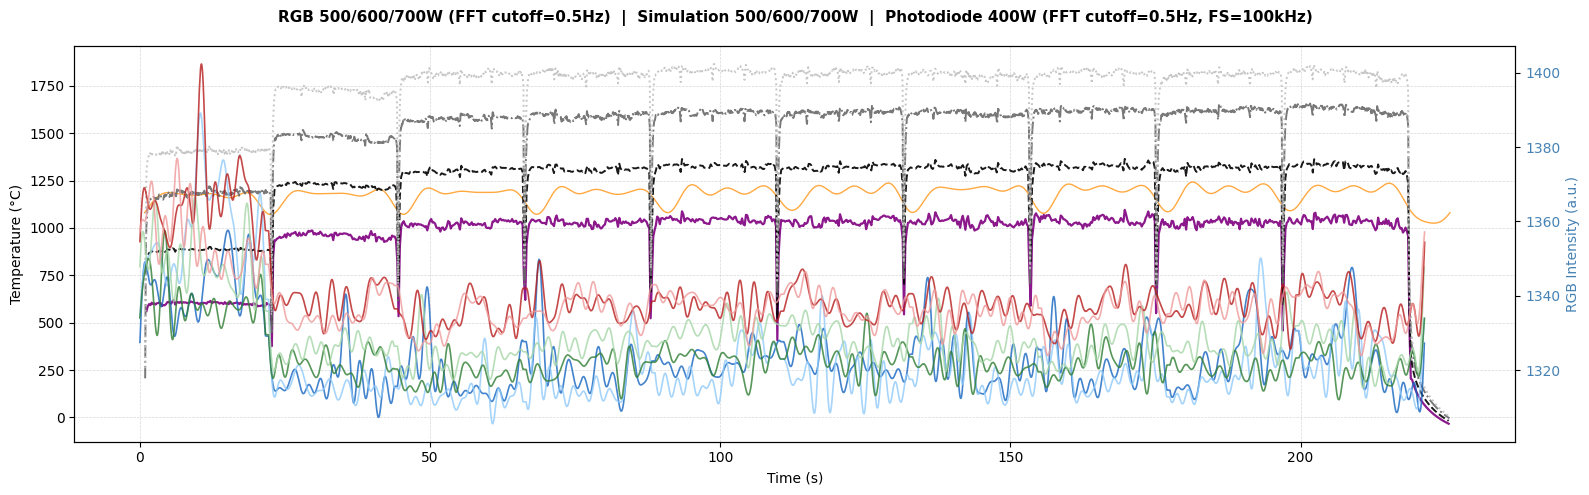

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ─── 1. HAMMER filtered 신호 ───
CUTOFF_HZ = 2

def get_filtered(df, cutoff=CUTOFF_HZ):
    sig = df["max_temp"].values
    n   = len(sig)
    dt  = df["time_norm"].diff().median()
    fft_vals     = np.fft.rfft(sig)
    fft_freq     = np.fft.rfftfreq(n, d=dt)
    fft_filtered = fft_vals.copy()
    fft_filtered[fft_freq > cutoff] = 0
    return np.fft.irfft(fft_filtered, n=n)

WATT_PALETTE = {
    "500W": ["#1565C0", "#90CAF9"],
    "600W": ["#2E7D32", "#A5D6A7"],
    "700W": ["#B71C1C", "#EF9A9A"],
}

# ─── 2. melt_pool_temperature + Laser_power ───
FILE_FULL = "/home/ftk3187/github/DPC_research/DATAFUSION/merged_df_2_99_temp_depth.csv"
df_all_full = pd.read_csv(FILE_FULL, usecols=["time_index", "melt_pool_temperature",
                                               "laser_power_number", "Laser_power"])

LP_STYLE = {
    91: {"color": "dimgray", "linestyle": "-.", "label": "Simulation 600W"},
    82: {"color": "silver",  "linestyle": ":",  "label": "Simulation 700W"},
}
LP_LIST      = [38, 91, 82]
LP_PLOT_LIST = [91, 82]

def moving_average_1d(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='valid')

WINDOW     = 4
TIME_SHIFT = 0.8

# ─── 3. 400W CSV 로드 및 전처리 + FFT ───
FILE_400W = "/home/ftk3187/github/DPC_research/DATAFUSION/data_400w/HT1-3-(240820)_PD_exp02_Single Track Square.csv"
df_400w = pd.read_csv(FILE_400W, header=None)
raw     = df_400w.iloc[:, 2].values

first_valid = max(0,          np.argmax(raw >= 1120) - 30000)
last_valid  = min(len(raw)-1, len(raw) - 1 - np.argmax(raw[::-1] >= 1120) + 260000)
raw_trimmed = raw[first_valid : last_valid + 1]
print(f"400W trimmed: {len(raw)} → {len(raw_trimmed)} samples  ({first_valid} ~ {last_valid})")

FS = 100_000
dt = 1 / FS
n  = len(raw_trimmed)

fft_vals     = np.fft.rfft(raw_trimmed - raw_trimmed.mean())
fft_freq     = np.fft.rfftfreq(n, d=dt)
fft_filtered = fft_vals.copy()
fft_filtered[fft_freq > CUTOFF_HZ] = 0
temp_400w_filtered = np.fft.irfft(fft_filtered, n=n) + raw_trimmed.mean()

df_ref    = df_all_full[df_all_full["laser_power_number"] == 38].reset_index(drop=True)
time_ref  = df_ref["time_index"].values
t_min_ref = time_ref[0]  + TIME_SHIFT
t_max_ref = time_ref[-1] + TIME_SHIFT
time_400w = np.linspace(t_min_ref, t_max_ref, len(temp_400w_filtered))

# ─── 4. sim_data 준비 ───
sim_data = {}
for lp in LP_LIST:
    df_lp   = df_all_full[df_all_full["laser_power_number"] == lp].reset_index(drop=True)
    temp_ma = moving_average_1d(df_lp["melt_pool_temperature"].values / 2 - 273, WINDOW)
    time_ma = df_lp["time_index"].values[WINDOW - 1:] + TIME_SHIFT
    pwr_ma  = df_lp["Laser_power"].values[WINDOW - 1:]
    sim_data[lp] = {"time": time_ma, "temp": temp_ma, "power": pwr_ma}

t_start  = max(d["time"][0]  for d in sim_data.values())
t_end    = min(d["time"][-1] for d in sim_data.values())
t_common = np.linspace(t_start, t_end, 1000)

interp_temp  = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["temp"])  for lp in LP_LIST}
interp_power = {lp: np.interp(t_common, sim_data[lp]["time"], sim_data[lp]["power"]) for lp in LP_LIST}

# ─── 5. extrapolation ───
def extrapolate(target_w):
    result = np.zeros(len(t_common))
    for i in range(len(t_common)):
        X = np.array([interp_power[lp][i] for lp in LP_LIST])
        Y = np.array([interp_temp[lp][i]  for lp in LP_LIST])
        coeffs = np.polyfit(X, Y, 1)
        result[i] = np.polyval(coeffs, target_w)
    return result

temp_extrap_400 = extrapolate(400)
temp_extrap_500 = extrapolate(500)

# ─── 6. 플롯 ───
fig, ax = plt.subplots(figsize=(16, 5))
ax2 = ax.twinx()   # RGB 전용 우측 축

fig.suptitle(
    f"RGB 500/600/700W (FFT cutoff={CUTOFF_HZ}Hz)  |  Simulation 500/600/700W  |  Photodiode 400W (FFT cutoff={CUTOFF_HZ}Hz, FS={FS//1000}kHz)",
    fontsize=11, fontweight="bold"
)

# ── 왼쪽 ax: Simulation + Photodiode ──
sim_handles, sim_labels = [], []

line, = ax.plot(time_400w, temp_400w_filtered,
                color="darkorange", linestyle="-", linewidth=1.0, alpha=0.75)
sim_handles.append(line); sim_labels.append("Photodiode 400W")

line, = ax.plot(t_common, temp_extrap_400,
                color="purple", linestyle="-", linewidth=1.6, alpha=0.9)
sim_handles.append(line); sim_labels.append("Simulation 400W (extrapolated)")

line, = ax.plot(t_common, temp_extrap_500,
                color="black", linestyle="--", linewidth=1.4, alpha=0.9)
sim_handles.append(line); sim_labels.append("Simulation 500W")

for lp in LP_PLOT_LIST:
    style = LP_STYLE[lp]
    line, = ax.plot(sim_data[lp]["time"], sim_data[lp]["temp"],
                    color=style["color"], linestyle=style["linestyle"],
                    linewidth=1.4, alpha=0.9)
    sim_handles.append(line); sim_labels.append(style["label"])

ax.set_ylabel("Temperature (°C)", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=10)

# ── 오른쪽 ax2: RGB 6개 ──
rgb_handles, rgb_labels = [], []
for watt, dfs in all_data.items():
    colors = WATT_PALETTE[watt]
    for run_idx, (df, color) in enumerate(zip(dfs, colors)):
        sig_f = get_filtered(df)
        t     = df["time_norm"].values[:len(sig_f)]
        line, = ax2.plot(t, sig_f, color=color, linewidth=1.2, alpha=0.8)
        rgb_handles.append(line)
        rgb_labels.append(f"RGB {watt}({run_idx+1})")

ax2.set_ylabel("RGB Intensity (a.u.)", fontsize=10, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.5)

# ─── legend: 3열 (RGB | Photodiode | Simulation) ───
blank = Patch(visible=False)
n_rows = 6

def pad(lst, n, fill):
    return lst + [fill] * (n - len(lst))

col1_h = pad(rgb_handles, n_rows, blank);   col1_l = pad(rgb_labels, n_rows, "")
col2_h = pad(sim_handles[:1], n_rows, blank); col2_l = pad(sim_labels[:1], n_rows, "")  # Photodiode만
col3_h = pad(sim_handles[1:], n_rows, blank); col3_l = pad(sim_labels[1:], n_rows, "")  # Simulation들

all_h = [col1_h[i] for i in range(n_rows)] + \
        [col2_h[i] for i in range(n_rows)] + \
        [col3_h[i] for i in range(n_rows)]
all_l = [col1_l[i] for i in range(n_rows)] + \
        [col2_l[i] for i in range(n_rows)] + \
        [col3_l[i] for i in range(n_rows)]

#ax.legend(all_h, all_l, fontsize=8, ncol=3, loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
"""
HAMMER Square — DTW 파형 유사도 분석
within-group (같은 와트 Run1 vs Run2) vs between-group (다른 와트) 비교
이전 셀에서 all_data, time_norm 로드된 상태 가정
"""

import numpy as np
from fastdtw import fastdtw

CUTOFF_HZ  = 1.0
DOWNSAMPLE = 100  # 200Hz → 2Hz

# ─── filtered + 다운샘플 신호 추출 ───────────────────────────────────────────
def get_filtered_ds(df, cutoff=CUTOFF_HZ, ds=DOWNSAMPLE):
    sig = df["max_temp"].values
    n   = len(sig)
    dt  = df["time_norm"].diff().median()
    fft_vals              = np.fft.rfft(sig)
    fft_freq              = np.fft.rfftfreq(n, d=dt)
    fft_filtered          = fft_vals.copy()
    fft_filtered[fft_freq > cutoff] = 0
    sig_f = np.fft.irfft(fft_filtered, n=n)
    return sig_f[::ds]  # 다운샘플

# 신호 준비: {watt: [run1_signal, run2_signal]}
signals = {
    watt: [get_filtered_ds(df) for df in dfs]
    for watt, dfs in all_data.items()
}

print(f"다운샘플 후 신호 길이: {len(list(signals.values())[0][0])} points")

# ─── DTW 거리 계산 ────────────────────────────────────────────────────────────
def dtw_dist(a, b):
    dist, _ = fastdtw(a, b, dist=lambda x, y: abs(x - y))
    # 길이로 정규화
    return dist / max(len(a), len(b))

print("\n" + "=" * 60)
print("DTW DISTANCE (normalized)")
print("=" * 60)

# Within-group
print("\n[Within-group] 같은 와트, Run1 vs Run2")
within_dists = {}
for watt, sigs in signals.items():
    d = dtw_dist(sigs[0], sigs[1])
    within_dists[watt] = d
    print(f"  {watt}  Run1 vs Run2  :  {d:.4f}")

# Between-group
print("\n[Between-group] 다른 와트 비교 (Run1끼리 / Run2끼리 평균)")
import itertools
between_dists = {}
for w1, w2 in itertools.combinations(signals.keys(), 2):
    d_r1 = dtw_dist(signals[w1][0], signals[w2][0])
    d_r2 = dtw_dist(signals[w1][1], signals[w2][1])
    d_avg = (d_r1 + d_r2) / 2
    between_dists[f"{w1} vs {w2}"] = d_avg
    print(f"  {w1} vs {w2}  :  R1={d_r1:.4f}  R2={d_r2:.4f}  avg={d_avg:.4f}")

# ─── 해석 요약 ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
avg_within  = np.mean(list(within_dists.values()))
avg_between = np.mean(list(between_dists.values()))
ratio = avg_between / avg_within

print(f"  평균 within-group  거리 : {avg_within:.4f}")
print(f"  평균 between-group 거리 : {avg_between:.4f}")
print(f"  between / within 비율  : {ratio:.2f}x")
print()
if ratio > 2.0:
    print("  ✅ 와트 분류가 의미있음 — 그룹 간 차이가 그룹 내 차이보다 훨씬 큼")
elif ratio > 1.2:
    print("  ⚠️  와트 분류가 어느 정도 의미있음 — 그룹 간 차이가 그룹 내보다 크지만 뚜렷하진 않음")
else:
    print("  ❌ 와트 분류 의미 약함 — 그룹 간/내 차이가 비슷함")

다운샘플 후 신호 길이: 435 points

DTW DISTANCE (normalized)

[Within-group] 같은 와트, Run1 vs Run2
  500W  Run1 vs Run2  :  5.6306
  600W  Run1 vs Run2  :  5.3128
  700W  Run1 vs Run2  :  3.9578

[Between-group] 다른 와트 비교 (Run1끼리 / Run2끼리 평균)
  500W vs 600W  :  R1=4.9651  R2=8.3072  avg=6.6362
  500W vs 700W  :  R1=13.3723  R2=14.0509  avg=13.7116
  600W vs 700W  :  R1=13.0226  R2=7.0370  avg=10.0298

SUMMARY
  평균 within-group  거리 : 4.9671
  평균 between-group 거리 : 10.1258
  between / within 비율  : 2.04x

  ✅ 와트 분류가 의미있음 — 그룹 간 차이가 그룹 내 차이보다 훨씬 큼


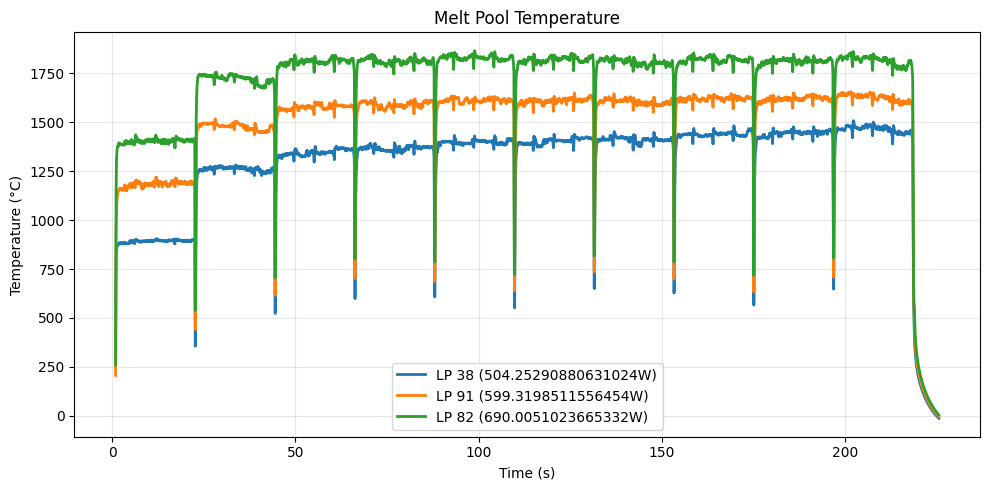

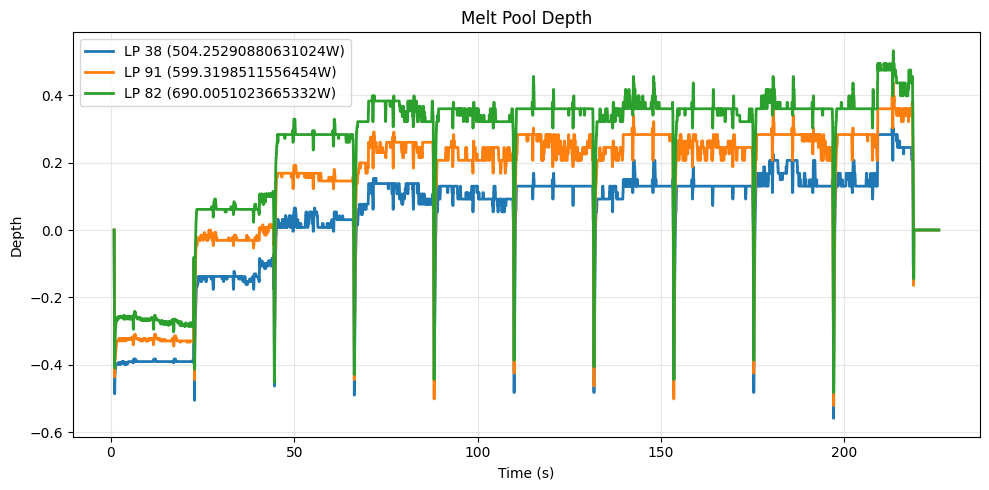

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. DATA LOAD
# =========================================================

FILE_FULL = "/home/ftk3187/github/DPC_research/DATAFUSION/merged_df_2_99_temp_depth.csv"

df_all = pd.read_csv(
    FILE_FULL,
    usecols=[
        "time_index",
        "laser_power_number",
        "Laser_power",
        "melt_pool_temperature",
        "melt_pool_depth",   # <-- 추가
    ]
)

# =========================================================
# 2. USER SETTING
# =========================================================

# 원하는 laser power number 지정
TARGET_LP = [38, 91, 82]
WINDOW = 4
TIME_SHIFT = 0.8

# =========================================================
# 3. MOVING AVERAGE FUNCTION
# =========================================================

def moving_average_1d(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='valid')

# =========================================================
# 4. DATA PREP
# =========================================================

plot_data = {}

for lp in TARGET_LP:

    df_lp = (
        df_all[df_all["laser_power_number"] == lp]
        .reset_index(drop=True)
    )

    if len(df_lp) == 0:
        print(f"[WARNING] laser_power_number={lp} not found")
        continue

    # temperature
    temp_ma = moving_average_1d(
        df_lp["melt_pool_temperature"].values / 2 - 273,
        WINDOW
    )

    # depth
    depth_ma = moving_average_1d(
        df_lp["melt_pool_depth"].values,
        WINDOW
    )

    # time
    time_ma = (
        df_lp["time_index"].values[WINDOW - 1:]
        + TIME_SHIFT
    )

    plot_data[lp] = {
        "time": time_ma,
        "temp": temp_ma,
        "depth": depth_ma,
        "laser_power": df_lp["Laser_power"].iloc[0],
    }

# =========================================================
# 5. TEMPERATURE PLOT
# =========================================================

plt.figure(figsize=(10, 5))

for lp, data in plot_data.items():

    plt.plot(
        data["time"],
        data["temp"],
        linewidth=2,
        label=f"LP {lp} ({data['laser_power']}W)"
    )

plt.title("Melt Pool Temperature")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. DEPTH PLOT
# =========================================================

plt.figure(figsize=(10, 5))

for lp, data in plot_data.items():

    plt.plot(
        data["time"],
        data["depth"],
        linewidth=2,
        label=f"LP {lp} ({data['laser_power']}W)"
    )

plt.title("Melt Pool Depth")
plt.xlabel("Time (s)")
plt.ylabel("Depth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()